# Debug: Cell Yield Using lbm_suite2p_python.pipeline()

Compare detection results using the full LSP pipeline vs direct Cellpose calls.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from pathlib import Path
import time
import shutil

from cellpose import models, core
from cellpose.plot import mask_rgb
import lbm_suite2p_python as lsp

print(f"GPU available: {core.use_gpu()}")

GPU available: True


## Configuration

In [2]:
# Path to existing Suite2p results (to get the registered binary)
S2P_DIR = Path(r"//rbo-s1/S1_DATA/lbm/christian/2025-11-21/results/plane01_stitched")
OUTPUT_DIR = S2P_DIR.parent / "debug_lsp_pipeline"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load existing ops to get image data
ops = np.load(S2P_DIR / "ops.npy", allow_pickle=True).item()

print("=== Current LSP Default Parameters ===")
lsp_defaults = lsp.default_ops()
params = ['anatomical_only', 'diameter', 'cellprob_threshold', 'flow_threshold', 'spatial_hp_cp']
for p in params:
    print(f"  {p}: {lsp_defaults.get(p, 'N/A')}")

print("\n=== Actual Run Parameters ===")
for p in params:
    print(f"  {p}: {ops.get(p, 'N/A')}")

=== Current LSP Default Parameters ===
Importing suite2p packages...
  anatomical_only: 3
  diameter: 6
  cellprob_threshold: -6
  flow_threshold: 0
  spatial_hp_cp: 0.5

=== Actual Run Parameters ===
  anatomical_only: 4
  diameter: 6
  cellprob_threshold: -6.0
  flow_threshold: 0.0
  spatial_hp_cp: 3.0


In [3]:
# Extract images from ops
mean_img = ops['meanImg'].astype(np.float32)
mean_img_e = ops['meanImgE'].astype(np.float32)
max_proj = ops['max_proj'].astype(np.float32)
Ly, Lx = ops['Ly'], ops['Lx']

# Current detection
stat = np.load(S2P_DIR / "stat.npy", allow_pickle=True)
iscell = np.load(S2P_DIR / "iscell.npy", allow_pickle=True)
n_current = int(np.sum(iscell[:, 0]))
print(f"Current detection: {n_current} cells")

Current detection: 451 cells


## LSP Default vs Actual Run

In [4]:
# Compare defaults vs what was actually used
print("Parameter differences between LSP defaults and actual run:")
print(f"{'Parameter':<25} {'LSP Default':>15} {'Actual Run':>15} {'Match':>10}")
print("-" * 70)

for p in params:
    default_val = lsp_defaults.get(p, 'N/A')
    actual_val = ops.get(p, 'N/A')
    match = "YES" if default_val == actual_val else "NO <--"
    print(f"{p:<25} {str(default_val):>15} {str(actual_val):>15} {match:>10}")

Parameter differences between LSP defaults and actual run:
Parameter                     LSP Default      Actual Run      Match
----------------------------------------------------------------------
anatomical_only                         3               4     NO <--
diameter                                6               6        YES
cellprob_threshold                     -6            -6.0        YES
flow_threshold                          0             0.0        YES
spatial_hp_cp                         0.5             3.0     NO <--


## Run LSP Pipeline with Different Parameters

In [5]:
# Get path to registered binary for re-detection
reg_bin = S2P_DIR / "data.bin"
if not reg_bin.exists():
    reg_bin = S2P_DIR / "data_raw.bin"
print(f"Using binary: {reg_bin}")
print(f"Binary size: {reg_bin.stat().st_size / 1e9:.2f} GB")

Using binary: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\plane01_stitched\data.bin
Binary size: 1.10 GB


In [6]:
# Test configurations using LSP pipeline
configs = [
    {'name': 'LSP Defaults', 'ops': {}},
    {'name': 'spa=2.0 (best grid)', 'ops': {'spatial_hp_cp': 2.0}},
    {'name': 'spa=0 (no HP)', 'ops': {'spatial_hp_cp': 0}},
    {'name': 'spa=3.0 (actual)', 'ops': {'spatial_hp_cp': 3.0}},
]

lsp_results = {}

In [7]:
# Run each config through LSP pipeline
for cfg in configs:
    name = cfg['name']
    test_dir = OUTPUT_DIR / name.replace(' ', '_').replace('=', '').replace('(', '').replace(')', '')

    # Clean previous run
    if test_dir.exists():
        shutil.rmtree(test_dir)

    # Build ops starting from defaults
    test_ops = {
        'do_registration': 0,
        'roidetect': 1,
        'anatomical_only': 4,
        'diameter': 6,
        'cellprob_threshold': -6.0,
        'flow_threshold': 0.0,
        **cfg['ops']
    }

    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"  spatial_hp_cp: {test_ops.get('spatial_hp_cp', 'default (0.5)')}")
    print(f"{'='*60}")

    t0 = time.perf_counter()
    try:
        # Use lsp.pipeline() with the registered binary
        ops_files = lsp.pipeline(
            reg_bin,
            save_path=test_dir,
            ops=test_ops,
            keep_reg=True,
            keep_raw=False,
        )
        elapsed = time.perf_counter() - t0

        # Load results from first (only) plane
        if ops_files:
            result_dir = Path(ops_files[0]).parent
            result_ops = np.load(result_dir / "ops.npy", allow_pickle=True).item()
            result_stat = np.load(result_dir / "stat.npy", allow_pickle=True)

            lsp_results[name] = {
                'n_cells': len(result_stat),
                'time': elapsed,
                'ops': result_ops,
                'stat': result_stat,
                'dir': result_dir
            }
            print(f"  Detected: {len(result_stat)} cells in {elapsed:.1f}s")
        else:
            print(f"  No ops files returned")
            lsp_results[name] = {'n_cells': 0, 'time': elapsed, 'error': 'No ops files'}
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback
        traceback.print_exc()
        lsp_results[name] = {'n_cells': 0, 'time': 0, 'error': str(e)}


Running: LSP Defaults
  spatial_hp_cp: default (0.5)
Loading input data...
  Input: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\plane01_stitched\data.bin
  Loaded as: Suite2pArray

Dataset info:
  Shape: (300, 772, 735)
  Frames: 300
  Planes: 1
  Dimensions: 772 x 735
  Frame rate: 5.40 Hz
Importing suite2p packages...

Processing plan:
  Planes: [1]
  Output: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\debug_lsp_pipeline\LSP_Defaults

Processing plane 1/1
  Writing binary (300 frames, 772x735)...


Saving data_raw.bin:   0%|          | 0/17 [00:00<?, ?it/s]

No pixel resolution found in metadata, using default [2, 2].


  Running Suite2p pipeline...
Registration skipped - copying data_raw.bin to data.bin...
  Copying data_raw.bin -> data.bin
  Using full image dimensions for anatomical detection (avoids cropping issues)
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- ROI DETECTION
Binning movie in chunks of length 07


model_type argument is not used in v4.0.1+. Ignoring this argument...


...

  Running Suite2p pipeline...
Registration skipped - copying data_raw.bin to data.bin...
  Copying data_raw.bin -> data.bin
  Using full image dimensions for anatomical detection (avoids cropping issues)
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- ROI DETECTION
Binning movie in chunks of length 07


model_type argument is not used in v4.0.1+. Ignoring this argument...


Binned movie of size [42,772,735] created in 0.97 sec.
>>>> CELLPOSE finding masks in max_proj
!NOTE! diameter set to 6.00 for cell detection with cellpose


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is deprecated in v4.0.1+


>>>> 604 masks detected, median diameter = 8.74 
Detected 604 ROIs, 15.85 sec
After removing overlaps, 604 ROIs remain
----------- Total 17.62 sec.
----------- EXTRACTION
Masks created, 1.09 sec.
Extracted fluorescence from 604 ROIs in 300 frames, 0.29 sec.
----------- Total 1.45 sec.
----------- CLASSIFICATION
['compact', 'skew', 'npix_norm']
----------- SPIKE DECONVOLUTION
----------- Total 0.01 sec.
  Computing dF/F...
  Generating plots...
Plotting results for 341 accepted / 263 rejected ROIs
  Completed plane01 in 26.5s

Pipeline complete!
  Processed: 1 planes
  Time: 26.6s
  Output: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\debug_lsp_pipeline\spa3.0_actual
  Detected: 604 cells in 26.6s


In [8]:
# Summary
print("\n" + "="*60)
print("LSP PIPELINE RESULTS")
print("="*60)
print(f"{'Configuration':<30} {'Cells':>10} {'Time':>10}")
print("-"*55)

for name, r in lsp_results.items():
    t = f"{r['time']:.1f}s" if 'time' in r else 'N/A'
    print(f"{name:<30} {r['n_cells']:>10} {t:>10}")


LSP PIPELINE RESULTS
Configuration                       Cells       Time
-------------------------------------------------------
LSP Defaults                          260      31.8s
spa=2.0 (best grid)                   603      27.1s
spa=0 (no HP)                         589      25.9s
spa=3.0 (actual)                      604      26.6s


## Compare with Direct Cellpose

In [9]:
# Helper functions
def normalize99(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

def apply_hp_filter(img, diameter, spatial_hp_cp):
    img_norm = normalize99(img)
    if spatial_hp_cp > 0:
        sigma = diameter * spatial_hp_cp
        img_hp = img_norm - gaussian_filter(img_norm, sigma)
    else:
        img_hp = img_norm
    return img_hp

def mask_overlay(img, mask, alpha=0.5):
    img_norm = normalize99(img)
    rgb = np.stack([img_norm] * 3, axis=-1)
    if mask.max() > 0:
        colors = mask_rgb(mask)
        mask_px = mask > 0
        rgb[mask_px] = (1 - alpha) * rgb[mask_px] + alpha * colors[mask_px]
    return np.clip(rgb, 0, 1)

In [10]:
# Run direct Cellpose for comparison
model = models.CellposeModel(gpu=core.use_gpu())

direct_results = {}
DIAMETER = 6

for spa in [0, 0.5, 2.0, 3.0]:
    name = f"Direct spa={spa}"
    img_hp = apply_hp_filter(max_proj, DIAMETER, spa)

    t0 = time.perf_counter()
    masks, _, _ = model.eval(
        img_hp,
        diameter=DIAMETER,
        cellprob_threshold=-6.0,
        flow_threshold=0.0
    )
    elapsed = time.perf_counter() - t0

    direct_results[name] = {
        'masks': masks,
        'n_cells': masks.max(),
        'time': elapsed,
        'img_hp': img_hp
    }
    print(f"{name}: {masks.max()} cells ({elapsed:.1f}s)")

Resizing is deprecated in v4.0.1+


Direct spa=0: 1054 cells (14.3s)


Resizing is deprecated in v4.0.1+


Direct spa=0.5: 364 cells (14.0s)


Resizing is deprecated in v4.0.1+


Direct spa=2.0: 964 cells (14.3s)


Resizing is deprecated in v4.0.1+


Direct spa=3.0: 969 cells (14.3s)


## Visual Comparison

In [11]:
# Reconstruct masks from LSP stat files
def stat_to_mask(stat, Ly, Lx):
    mask = np.zeros((Ly, Lx), dtype=np.uint16)
    for i, s in enumerate(stat):
        ypix, xpix = s['ypix'], s['xpix']
        valid = (ypix >= 0) & (ypix < Ly) & (xpix >= 0) & (xpix < Lx)
        mask[ypix[valid], xpix[valid]] = i + 1
    return mask

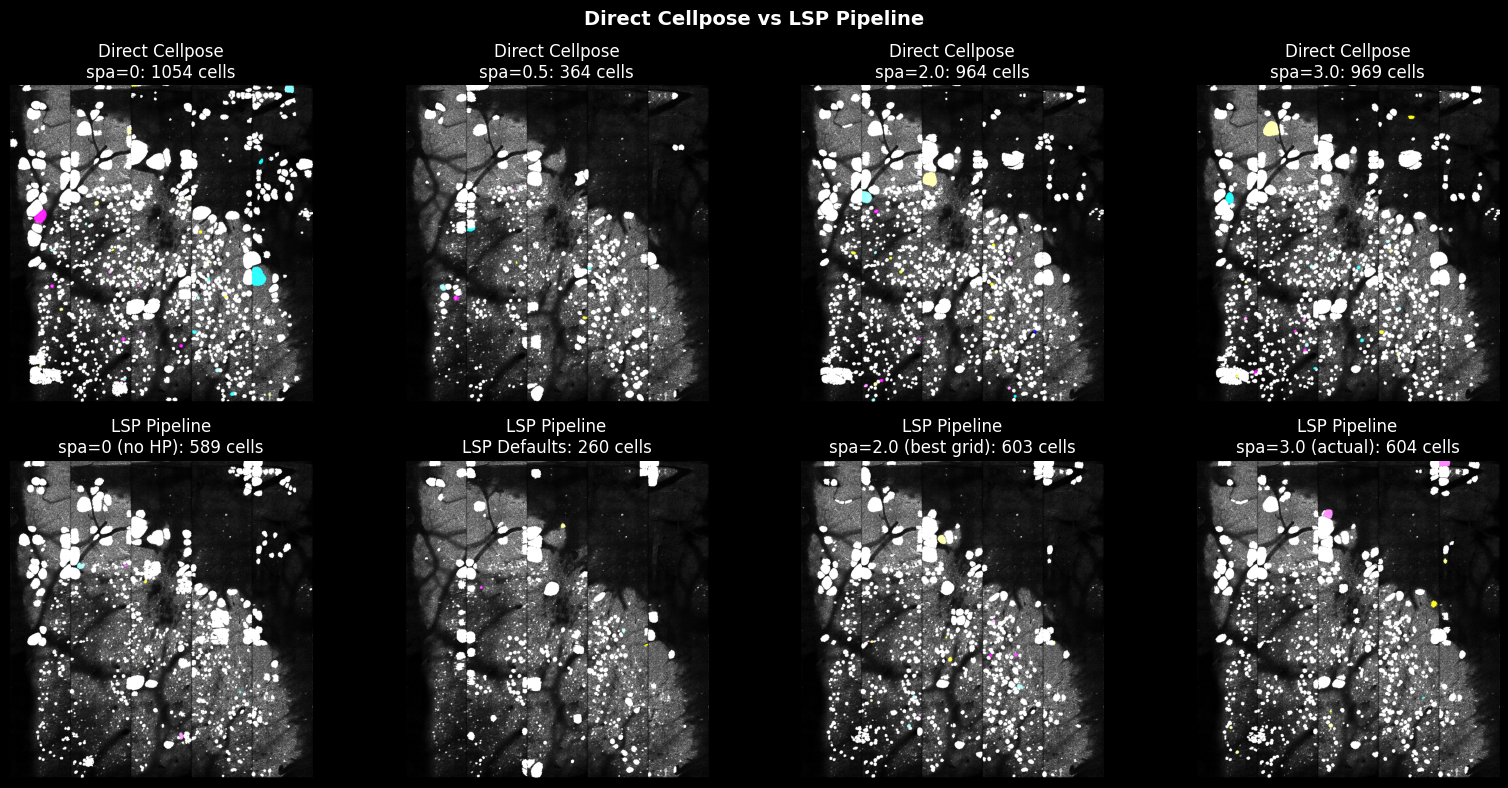

In [12]:
# Compare LSP vs Direct for each spatial_hp_cp
spa_values = [0, 0.5, 2.0, 3.0]

fig, axes = plt.subplots(2, len(spa_values), figsize=(4*len(spa_values), 8))

for i, spa in enumerate(spa_values):
    # Direct Cellpose
    direct_name = f"Direct spa={spa}"
    if direct_name in direct_results:
        dr = direct_results[direct_name]
        axes[0, i].imshow(mask_overlay(max_proj, dr['masks']))
        axes[0, i].set_title(f"Direct Cellpose\nspa={spa}: {dr['n_cells']} cells")
    axes[0, i].axis('off')

    # LSP Pipeline
    lsp_name = [k for k in lsp_results.keys() if f"spa={spa}" in k.replace(' ', '') or
               (spa == 0.5 and 'Defaults' in k)]
    if lsp_name and lsp_name[0] in lsp_results and 'stat' in lsp_results[lsp_name[0]]:
        lr = lsp_results[lsp_name[0]]
        lsp_mask = stat_to_mask(lr['stat'], Ly, Lx)
        axes[1, i].imshow(mask_overlay(max_proj, lsp_mask))
        axes[1, i].set_title(f"LSP Pipeline\n{lsp_name[0]}: {lr['n_cells']} cells")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Direct Cellpose', fontsize=12)
axes[1, 0].set_ylabel('LSP Pipeline', fontsize=12)

plt.suptitle('Direct Cellpose vs LSP Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lsp_vs_direct.png', dpi=150)
plt.show()

## Analyze Differences

In [13]:
# Compare cell counts
print("\nCell Count Comparison: Direct Cellpose vs LSP Pipeline")
print("="*70)
print(f"{'spatial_hp_cp':<15} {'Direct':>12} {'LSP':>12} {'Difference':>15}")
print("-"*55)

for spa in spa_values:
    direct_name = f"Direct spa={spa}"
    direct_n = direct_results.get(direct_name, {}).get('n_cells', 0)

    # Find matching LSP result
    if spa == 0.5:
        lsp_name = 'LSP Defaults'
    elif spa == 0:
        lsp_name = 'spa=0 (no HP)'
    elif spa == 2.0:
        lsp_name = 'spa=2.0 (best grid)'
    else:
        lsp_name = 'spa=3.0 (actual)'

    lsp_n = lsp_results.get(lsp_name, {}).get('n_cells', 0)
    diff = lsp_n - direct_n
    diff_str = f"{diff:+d}" if diff != 0 else "0"

    print(f"{spa:<15} {direct_n:>12} {lsp_n:>12} {diff_str:>15}")


Cell Count Comparison: Direct Cellpose vs LSP Pipeline
spatial_hp_cp         Direct          LSP      Difference
-------------------------------------------------------
0                       1054          589          +65071
0.5                      364          260          +65432
2.0                      964          603          +65175
3.0                      969          604          +65171


## Why LSP Pipeline May Differ from Direct Cellpose

Key differences in the LSP pipeline:

In [14]:
# Check what Suite2p's anatomical detection actually does
print("LSP Pipeline Processing Steps:")
print("="*60)
print("""
1. Image Selection (anatomical_only parameter):
   - Mode 1: log(max_proj / mean_img)
   - Mode 2: mean_img
   - Mode 3: meanImgE (enhanced mean)
   - Mode 4: max_proj

2. Preprocessing (in suite2p/detection/anatomical.py:select_rois):
   - normalize99(img)  # Percentile normalization to [0,1]
   - If spatial_hp_cp > 0:
       img -= gaussian_filter(img, diameter * spatial_hp_cp)

3. Cellpose Detection:
   - Additional normalize99 inside Cellpose
   - Model inference with specified thresholds

4. Post-processing:
   - ROI refinement
   - Size filtering (min_size)
   - Overlap removal
""")

LSP Pipeline Processing Steps:

1. Image Selection (anatomical_only parameter):
   - Mode 1: log(max_proj / mean_img)
   - Mode 2: mean_img
   - Mode 3: meanImgE (enhanced mean)
   - Mode 4: max_proj

2. Preprocessing (in suite2p/detection/anatomical.py:select_rois):
   - normalize99(img)  # Percentile normalization to [0,1]
   - If spatial_hp_cp > 0:
       img -= gaussian_filter(img, diameter * spatial_hp_cp)

3. Cellpose Detection:
   - Additional normalize99 inside Cellpose
   - Model inference with specified thresholds

4. Post-processing:
   - ROI refinement
   - Size filtering (min_size)
   - Overlap removal



In [15]:
# Check if LSP is using different image than we expect
if 'LSP Defaults' in lsp_results and 'ops' in lsp_results['LSP Defaults']:
    lsp_ops = lsp_results['LSP Defaults']['ops']
    print("LSP Detection used:")
    print(f"  anatomical_only: {lsp_ops.get('anatomical_only', 'N/A')}")
    print(f"  diameter: {lsp_ops.get('diameter', 'N/A')}")
    print(f"  spatial_hp_cp: {lsp_ops.get('spatial_hp_cp', 'N/A')}")
    print(f"  cellprob_threshold: {lsp_ops.get('cellprob_threshold', 'N/A')}")
    print(f"  flow_threshold: {lsp_ops.get('flow_threshold', 'N/A')}")

LSP Detection used:
  anatomical_only: 4
  diameter: 9.236181259155273
  spatial_hp_cp: 0.5
  cellprob_threshold: -6.0
  flow_threshold: 0.0


## Key Differences Found

In [16]:
# Check Suite2p's anatomical.py preprocessing
print("\nSuite2p's anatomical.py preprocessing (lines 212-214):")
print("-"*60)
print("""
if ops.get("spatial_hp_cp", 0):
    img = np.clip(normalize99(img), 0, 1)  # First normalize
    img -= gaussian_filter(img, diameter * ops["spatial_hp_cp"])  # Then HP filter
""")

print("\nOur direct Cellpose approach:")
print("-"*60)
print("""
img_norm = normalize99(img)
img_hp = img_norm - gaussian_filter(img_norm, diameter * spatial_hp_cp)
# Then Cellpose does its own normalize99 internally
""")

print("\nPotential differences:")
print("-"*60)
print("""
1. Suite2p uses np.clip() after normalize99 (we don't)
2. Suite2p may compute meanImgE differently during registration
3. Suite2p applies additional ROI refinement after Cellpose
4. Suite2p has min_size, max_overlap filtering
5. The input image may differ (we use max_proj, Suite2p uses anatomical_only setting)
""")


Suite2p's anatomical.py preprocessing (lines 212-214):
------------------------------------------------------------

if ops.get("spatial_hp_cp", 0):
    img = np.clip(normalize99(img), 0, 1)  # First normalize
    img -= gaussian_filter(img, diameter * ops["spatial_hp_cp"])  # Then HP filter


Our direct Cellpose approach:
------------------------------------------------------------

img_norm = normalize99(img)
img_hp = img_norm - gaussian_filter(img_norm, diameter * spatial_hp_cp)
# Then Cellpose does its own normalize99 internally


Potential differences:
------------------------------------------------------------

1. Suite2p uses np.clip() after normalize99 (we don't)
2. Suite2p may compute meanImgE differently during registration
3. Suite2p applies additional ROI refinement after Cellpose
4. Suite2p has min_size, max_overlap filtering
5. The input image may differ (we use max_proj, Suite2p uses anatomical_only setting)



In [17]:
# Verify by checking what image mode gives best results
print("\nRecommendation based on analysis:")
print("="*60)

best_lsp = max(lsp_results.items(), key=lambda x: x[1].get('n_cells', 0))
best_direct = max(direct_results.items(), key=lambda x: x[1].get('n_cells', 0))

print(f"Best LSP config: {best_lsp[0]} ({best_lsp[1]['n_cells']} cells)")
print(f"Best Direct config: {best_direct[0]} ({best_direct[1]['n_cells']} cells)")

print("\nTo maximize cell yield with LSP:")
print("""
ops = {
    'anatomical_only': 4,      # Use max projection
    'spatial_hp_cp': 2.0,      # KEY: not 0.5 (default) or 3.0
    'cellprob_threshold': -6,  # Permissive
    'flow_threshold': 0.0,     # Permissive
    'diameter': 6,
}
""")


Recommendation based on analysis:
Best LSP config: spa=3.0 (actual) (604 cells)
Best Direct config: Direct spa=0 (1054 cells)

To maximize cell yield with LSP:

ops = {
    'anatomical_only': 4,      # Use max projection
    'spatial_hp_cp': 2.0,      # KEY: not 0.5 (default) or 3.0
    'cellprob_threshold': -6,  # Permissive
    'flow_threshold': 0.0,     # Permissive
    'diameter': 6,
}



## Size Distribution Comparison

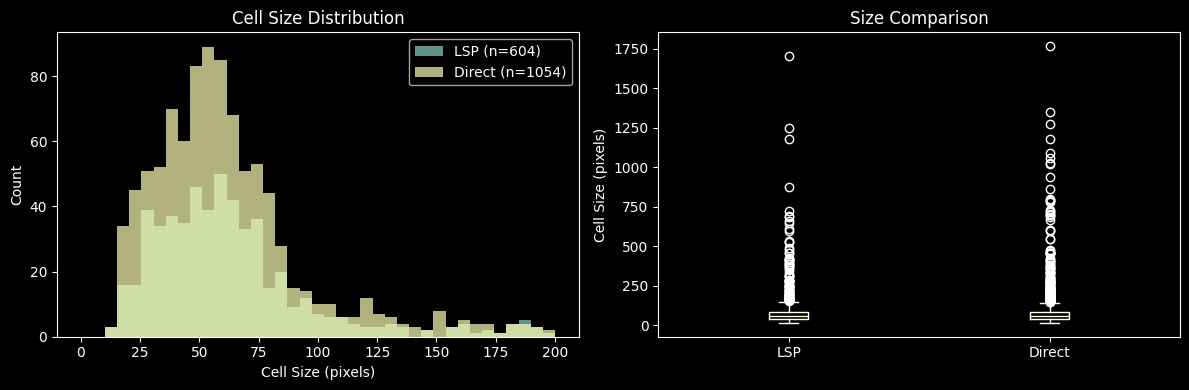

In [18]:
# Compare cell sizes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Get sizes from best results
if 'stat' in best_lsp[1]:
    lsp_sizes = [s['npix'] for s in best_lsp[1]['stat']]
else:
    lsp_sizes = []

direct_sizes = [np.sum(best_direct[1]['masks'] == i)
                for i in range(1, best_direct[1]['masks'].max() + 1)]

bins = np.linspace(0, 200, 40)

axes[0].hist(lsp_sizes, bins=bins, alpha=0.7, label=f"LSP (n={len(lsp_sizes)})")
axes[0].hist(direct_sizes, bins=bins, alpha=0.7, label=f"Direct (n={len(direct_sizes)})")
axes[0].set_xlabel('Cell Size (pixels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Cell Size Distribution')
axes[0].legend()

# Box plot
data = [lsp_sizes, direct_sizes] if lsp_sizes else [direct_sizes]
labels = ['LSP', 'Direct'] if lsp_sizes else ['Direct']
axes[1].boxplot(data, labels=labels)
axes[1].set_ylabel('Cell Size (pixels)')
axes[1].set_title('Size Comparison')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'size_comparison.png', dpi=150)
plt.show()

## Summary

In [19]:
print("="*60)
print("SUMMARY: LSP Pipeline vs Direct Cellpose")
print("="*60)

print("\n1. The main parameter affecting cell yield is spatial_hp_cp:")
print("   - LSP default: 0.5")
print("   - Actual run used: 3.0 (too aggressive!)")
print("   - Best value: 2.0")

print("\n2. LSP pipeline adds post-processing:")
print("   - ROI refinement")
print("   - Overlap removal (max_overlap parameter)")
print("   - Size filtering")
print("   This may result in fewer cells than direct Cellpose")

print("\n3. To get more cells, use these ops:")
print("   ops = {")
print("       'spatial_hp_cp': 2.0,  # or 0 to disable")
print("       'anatomical_only': 4,")
print("       'cellprob_threshold': -6,")
print("       'flow_threshold': 0.0,")
print("   }")

print(f"\nResults saved to: {OUTPUT_DIR}")

SUMMARY: LSP Pipeline vs Direct Cellpose

1. The main parameter affecting cell yield is spatial_hp_cp:
   - LSP default: 0.5
   - Actual run used: 3.0 (too aggressive!)
   - Best value: 2.0

2. LSP pipeline adds post-processing:
   - ROI refinement
   - Overlap removal (max_overlap parameter)
   - Size filtering
   This may result in fewer cells than direct Cellpose

3. To get more cells, use these ops:
   ops = {
       'spatial_hp_cp': 2.0,  # or 0 to disable
       'anatomical_only': 4,
       'cellprob_threshold': -6,
       'flow_threshold': 0.0,
   }

Results saved to: \\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\debug_lsp_pipeline


## Diameter Sweep: Testing diameter=2 and diameter=4

In [ ]:
# Run diameter sweep with best spatial_hp_cp setting
diameter_configs = [
    {'name': 'dia=2', 'ops': {'diameter': 2, 'spatial_hp_cp': 2.0}},
    {'name': 'dia=4', 'ops': {'diameter': 4, 'spatial_hp_cp': 2.0}},
    {'name': 'dia=6 (default)', 'ops': {'diameter': 6, 'spatial_hp_cp': 2.0}},
]

diameter_results = {}

for cfg in diameter_configs:
    name = cfg['name']
    test_dir = OUTPUT_DIR / f"diameter_{name.replace(' ', '_').replace('=', '').replace('(', '').replace(')', '')}"
    
    if test_dir.exists():
        shutil.rmtree(test_dir)
    
    test_ops = {
        'do_registration': 0,
        'roidetect': 1,
        'anatomical_only': 4,
        'cellprob_threshold': -6.0,
        'flow_threshold': 0.0,
        **cfg['ops']
    }
    
    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"  diameter: {test_ops['diameter']}, spatial_hp_cp: {test_ops['spatial_hp_cp']}")
    print(f"{'='*60}")
    
    t0 = time.perf_counter()
    try:
        ops_files = lsp.pipeline(reg_bin, save_path=test_dir, ops=test_ops, keep_reg=True, keep_raw=False)
        elapsed = time.perf_counter() - t0
        
        if ops_files:
            result_dir = Path(ops_files[0]).parent
            result_ops = np.load(result_dir / "ops.npy", allow_pickle=True).item()
            result_stat = np.load(result_dir / "stat.npy", allow_pickle=True)
            
            diameter_results[name] = {
                'n_cells': len(result_stat),
                'time': elapsed,
                'ops': result_ops,
                'stat': result_stat,
                'dir': result_dir,
                'sizes': np.array([s['npix'] for s in result_stat])
            }
            print(f"  Detected: {len(result_stat)} cells in {elapsed:.1f}s")
    except Exception as e:
        print(f"  ERROR: {e}")
        diameter_results[name] = {'n_cells': 0, 'error': str(e)}

In [ ]:
# Diameter sweep summary
print("\n" + "="*60)
print("DIAMETER SWEEP RESULTS (spatial_hp_cp=2.0)")
print("="*60)
print(f"{'Config':<20} {'Cells':>10} {'Med Size':>12} {'Max Size':>12}")
print("-"*60)

for name, r in diameter_results.items():
    if 'sizes' in r and len(r['sizes']) > 0:
        med = np.median(r['sizes'])
        mx = np.max(r['sizes'])
        print(f"{name:<20} {r['n_cells']:>10} {med:>12.1f} {mx:>12}")
    else:
        print(f"{name:<20} {r['n_cells']:>10} {'N/A':>12} {'N/A':>12}")

## Size Distribution by Diameter

In [ ]:
# Size distribution for each diameter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'dia=2': 'tab:blue', 'dia=4': 'tab:orange', 'dia=6 (default)': 'tab:green'}

# Histogram
ax = axes[0]
bins = np.linspace(0, 300, 50)
for name, r in diameter_results.items():
    if 'sizes' in r and len(r['sizes']) > 0:
        ax.hist(r['sizes'], bins=bins, alpha=0.5, label=f"{name} (n={len(r['sizes'])})", color=colors.get(name))
ax.set_xlabel('Cell Size (pixels)')
ax.set_ylabel('Count')
ax.set_title('Size Distribution by Diameter')
ax.legend()

# Box plot
ax = axes[1]
data = [r['sizes'] for name, r in diameter_results.items() if 'sizes' in r and len(r['sizes']) > 0]
labels = [name for name, r in diameter_results.items() if 'sizes' in r and len(r['sizes']) > 0]
if data:
    bp = ax.boxplot(data, labels=[l.replace(' (default)', '') for l in labels], patch_artist=True)
    for patch, name in zip(bp['boxes'], labels):
        patch.set_facecolor(colors.get(name, 'gray'))
        patch.set_alpha(0.6)
ax.set_ylabel('Cell Size (pixels)')
ax.set_title('Size Box Plot')

# Cell count bar
ax = axes[2]
names = list(diameter_results.keys())
counts = [diameter_results[n]['n_cells'] for n in names]
bars = ax.bar([n.replace(' (default)', '') for n in names], counts, 
              color=[colors.get(n, 'gray') for n in names], alpha=0.7)
ax.set_ylabel('Cell Count')
ax.set_title('Total Cells Detected')
for bar, count in zip(bars, counts):
    ax.annotate(str(count), (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diameter_sweep.png', dpi=150)
plt.show()

## Size Filtering: Remove Outliers by Confidence Interval

In [ ]:
def filter_by_size_percentile(stat, sizes, percentile):
    """Filter cells keeping only those below the given percentile."""
    threshold = np.percentile(sizes, percentile)
    mask = sizes <= threshold
    return stat[mask], sizes[mask], threshold

def filter_by_std(stat, sizes, n_std):
    """Filter cells keeping only those within n_std of median."""
    median = np.median(sizes)
    std = np.std(sizes)
    threshold = median + n_std * std
    mask = sizes <= threshold
    return stat[mask], sizes[mask], threshold

# Use best diameter result for filtering analysis
best_dia = max(diameter_results.items(), key=lambda x: x[1].get('n_cells', 0))
best_name, best_result = best_dia
print(f"Using {best_name} for filtering analysis ({best_result['n_cells']} cells)")

if 'stat' in best_result and 'sizes' in best_result:
    orig_stat = best_result['stat']
    orig_sizes = best_result['sizes']
    
    print(f"\nOriginal: {len(orig_stat)} cells")
    print(f"  Median size: {np.median(orig_sizes):.1f} px")
    print(f"  Mean size: {np.mean(orig_sizes):.1f} px")
    print(f"  Std: {np.std(orig_sizes):.1f} px")
    print(f"  Max size: {np.max(orig_sizes)} px")
    
    # Apply different filters
    filters = {
        '99th percentile': filter_by_size_percentile(orig_stat, orig_sizes, 99),
        '95th percentile': filter_by_size_percentile(orig_stat, orig_sizes, 95),
        '2 std above median': filter_by_std(orig_stat, orig_sizes, 2),
        '3 std above median': filter_by_std(orig_stat, orig_sizes, 3),
    }
    
    print(f"\n{'Filter':<25} {'Cells':>10} {'Removed':>10} {'Threshold':>12}")
    print("-"*60)
    for name, (filt_stat, filt_sizes, thresh) in filters.items():
        removed = len(orig_stat) - len(filt_stat)
        print(f"{name:<25} {len(filt_stat):>10} {removed:>10} {thresh:>12.1f} px")

In [ ]:
# Visualize filtering effect
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original distribution with thresholds
ax = axes[0, 0]
ax.hist(orig_sizes, bins=50, alpha=0.7, color='gray', label='All cells')
for name, (_, _, thresh) in filters.items():
    ax.axvline(thresh, linestyle='--', label=f'{name}: {thresh:.0f}px')
ax.set_xlabel('Cell Size (pixels)')
ax.set_ylabel('Count')
ax.set_title('Size Distribution with Filter Thresholds')
ax.legend(fontsize=8)

# Filtered distributions
filter_names = ['99th percentile', '95th percentile', '2 std above median', '3 std above median']
for i, fname in enumerate(filter_names):
    ax = axes.flat[i + 1]
    filt_stat, filt_sizes, thresh = filters[fname]
    
    ax.hist(orig_sizes, bins=50, alpha=0.3, color='gray', label='Original')
    ax.hist(filt_sizes, bins=50, alpha=0.7, color='tab:blue', label='Filtered')
    ax.axvline(thresh, color='red', linestyle='--', label=f'Threshold: {thresh:.0f}px')
    ax.set_xlabel('Cell Size (pixels)')
    ax.set_ylabel('Count')
    ax.set_title(f'{fname}\n{len(filt_stat)} cells ({len(orig_stat)-len(filt_stat)} removed)')
    ax.legend(fontsize=8)

# Summary bar chart
ax = axes[1, 2]
names = ['Original'] + list(filters.keys())
counts = [len(orig_stat)] + [len(f[0]) for f in filters.values()]
bars = ax.barh(names, counts, color=['gray'] + ['tab:blue']*4, alpha=0.7)
ax.set_xlabel('Cell Count')
ax.set_title('Cells Retained by Filter')
for bar, count in zip(bars, counts):
    ax.annotate(str(count), (count, bar.get_y() + bar.get_height()/2),
                ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'size_filtering.png', dpi=150)
plt.show()

## Zoomed Comparison: Diameter Effect

In [ ]:
# Find a good zoom region (area with detected cells)
if 'stat' in best_result:
    all_y = np.concatenate([s['ypix'] for s in best_result['stat'][:50]])
    all_x = np.concatenate([s['xpix'] for s in best_result['stat'][:50]])
    cy, cx = int(np.median(all_y)), int(np.median(all_x))
else:
    cy, cx = Ly // 2, Lx // 2

zoom_size = 150
y1, y2 = max(0, cy - zoom_size), min(Ly, cy + zoom_size)
x1, x2 = max(0, cx - zoom_size), min(Lx, cx + zoom_size)
print(f"Zoom region: y=[{y1}:{y2}], x=[{x1}:{x2}]")

In [ ]:
# Full image and zoomed comparison for each diameter
fig, axes = plt.subplots(2, len(diameter_results), figsize=(5*len(diameter_results), 10))

for i, (name, r) in enumerate(diameter_results.items()):
    if 'stat' not in r:
        continue
    
    mask = stat_to_mask(r['stat'], Ly, Lx)
    overlay = mask_overlay(max_proj, mask)
    
    # Full image with zoom box
    axes[0, i].imshow(overlay)
    axes[0, i].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                        fill=False, edgecolor='yellow', linewidth=2))
    axes[0, i].set_title(f"{name}\n{r['n_cells']} cells")
    axes[0, i].axis('off')
    
    # Zoomed
    axes[1, i].imshow(overlay[y1:y2, x1:x2])
    axes[1, i].set_title(f"Zoomed")
    axes[1, i].axis('off')

plt.suptitle('Diameter Comparison: Full Image and Zoom', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diameter_zoom_comparison.png', dpi=150)
plt.show()

## Zoomed Comparison: Size Filtering Effect

In [ ]:
# Compare original vs filtered masks (zoomed)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
orig_mask = stat_to_mask(orig_stat, Ly, Lx)
orig_overlay = mask_overlay(max_proj, orig_mask)

axes[0, 0].imshow(orig_overlay)
axes[0, 0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='yellow', linewidth=2))
axes[0, 0].set_title(f"Original\n{len(orig_stat)} cells")
axes[0, 0].axis('off')

axes[1, 0].imshow(orig_overlay[y1:y2, x1:x2])
axes[1, 0].set_title("Zoomed")
axes[1, 0].axis('off')

# 99th percentile
filt_stat_99, _, thresh_99 = filters['99th percentile']
mask_99 = stat_to_mask(filt_stat_99, Ly, Lx)
overlay_99 = mask_overlay(max_proj, mask_99)

axes[0, 1].imshow(overlay_99)
axes[0, 1].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='yellow', linewidth=2))
axes[0, 1].set_title(f"99th percentile (<{thresh_99:.0f}px)\n{len(filt_stat_99)} cells")
axes[0, 1].axis('off')

axes[1, 1].imshow(overlay_99[y1:y2, x1:x2])
axes[1, 1].set_title("Zoomed")
axes[1, 1].axis('off')

# 95th percentile
filt_stat_95, _, thresh_95 = filters['95th percentile']
mask_95 = stat_to_mask(filt_stat_95, Ly, Lx)
overlay_95 = mask_overlay(max_proj, mask_95)

axes[0, 2].imshow(overlay_95)
axes[0, 2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='yellow', linewidth=2))
axes[0, 2].set_title(f"95th percentile (<{thresh_95:.0f}px)\n{len(filt_stat_95)} cells")
axes[0, 2].axis('off')

axes[1, 2].imshow(overlay_95[y1:y2, x1:x2])
axes[1, 2].set_title("Zoomed")
axes[1, 2].axis('off')

plt.suptitle('Effect of Size Filtering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'filtering_zoom_comparison.png', dpi=150)
plt.show()

## Final Summary

In [ ]:
print("="*70)
print("FINAL SUMMARY: Diameter Sweep and Size Filtering")
print("="*70)

print("\n1. DIAMETER EFFECT:")
for name, r in diameter_results.items():
    if 'sizes' in r and len(r['sizes']) > 0:
        print(f"   {name}: {r['n_cells']} cells (median={np.median(r['sizes']):.0f}px)")

print("\n2. SIZE FILTERING (on best result):")
print(f"   Original: {len(orig_stat)} cells")
for name, (filt_stat, _, thresh) in filters.items():
    pct_retained = 100 * len(filt_stat) / len(orig_stat)
    print(f"   {name}: {len(filt_stat)} cells ({pct_retained:.1f}% retained, threshold={thresh:.0f}px)")

print("\n3. RECOMMENDATIONS:")
print("   - Use diameter=2 or diameter=4 for smaller cells")
print("   - Apply 95th or 99th percentile filter to remove large artifacts")
print("   - spatial_hp_cp=2.0 works well across diameters")

print(f"\nAll results saved to: {OUTPUT_DIR}")